In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

from experimentStruct import ExperimentStruct
import yaml

# Pull out a epoch of data from yaml file
exp_yaml = r'/Users/nick/Projects/cheeseboardAnalysis/DATA/concatenated.yaml'
board_file = r'/Users/nick/Projects/cheeseboardAnalysis/DATA/board_calibration_concat.csv'

with open(exp_yaml, 'r') as f:
        exp_dict = yaml.safe_load(f)
    # Group data by epoch, making sure that each epoch has a train, inter, and test file within a dictionary
grouped_data = {}
for epoch, data in exp_dict.items():
    if 'Train' in data and 'Inter' in data and 'Test' in data:
        grouped_data[epoch] = {
            'Train': data['Train'],
            'Inter': data['Inter'],
            'Test': data['Test']
            }

/Users/nick/Projects/cheeseboardAnalysis/PIPELINE/experimentStruct.py:567: RuntimeWarning: invalid value encountered in divide
  cos_angle = (deltaA_x * deltaC_x + deltaA_y * deltaC_y) / (np.sqrt(deltaA_x**2 + deltaA_y**2) * np.sqrt(deltaC_x**2 + deltaC_y**2))
/Users/nick/Projects/cheeseboardAnalysis/PIPELINE/experimentStruct.py:568: RuntimeWarning: invalid value encountered in arccos
  angles = np.arccos(cos_angle) * (180 / np.pi)
/Users/nick/Projects/cheeseboardAnalysis/PIPELINE/experimentStruct.py:567: RuntimeWarning: invalid value encountered in divide
  cos_angle = (deltaA_x * deltaC_x + deltaA_y * deltaC_y) / (np.sqrt(deltaA_x**2 + deltaA_y**2) * np.sqrt(deltaC_x**2 + deltaC_y**2))
/Users/nick/Projects/cheeseboardAnalysis/PIPELINE/experimentStruct.py:568: RuntimeWarning: invalid value encountered in arccos
  angles = np.arccos(cos_angle) * (180 / np.pi)


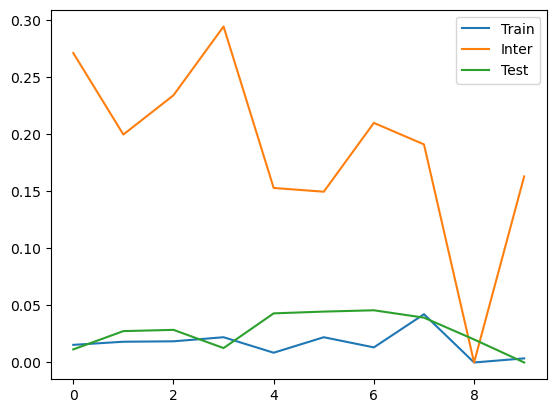

In [19]:
epoch = 'Epoch4Hour13N4'

train = ExperimentStruct(grouped_data[epoch]['Train'][0], board_file)
inter = ExperimentStruct(grouped_data[epoch]['Inter'][0], board_file)
test = ExperimentStruct(grouped_data[epoch]['Test'][0], board_file)

angles0 = test.calculate_angle_distribution(9)

# Compare distribution of angles across trials. To do this, calculate angle distributions for each trial, then
# Compare distributions using a 2D similarity metric like KL divergence implemented with scipy.stats.entropy. This will give a measure of how similar the angle distributions are across trials, which can be related to spatial information content.
kls_train = []
for trial_num in train.trial_data['trial_num'].unique():
    angles = train.calculate_angle_distribution(trial_num)
    kl_divergence = entropy(angles0, angles)

    # Drop the inf and nan values from the KL divergence calculation, then calculate the average KL divergence across all bins to get a single value for each trial. This will allow you to compare the overall similarity of the angle distributions across trials.
    kl_divergence = kl_divergence[np.isfinite(kl_divergence)]
    kl_divergence = np.mean(kl_divergence)
    kls_train.append(kl_divergence)
    # print(f'Trial {trial_num} KL Divergence: {kl_divergence:.4f}')

kls_inter = []
for trial_num in inter.trial_data['trial_num'].unique():
    angles = inter.calculate_angle_distribution(trial_num)
    kl_divergence = entropy(angles0, angles)

    # Drop the inf and nan values from the KL divergence calculation, then calculate the average KL divergence across all bins to get a single value for each trial. This will allow you to compare the overall similarity of the angle distributions across trials.
    kl_divergence = kl_divergence[np.isfinite(kl_divergence)]
    kl_divergence = np.mean(kl_divergence)
    kls_inter.append(kl_divergence)
    # print(f'Trial {trial_num} KL Divergence: {kl_divergence:.4f}')

kls_test = []
for trial_num in test.trial_data['trial_num'].unique():
    angles = test.calculate_angle_distribution(trial_num)
    kl_divergence = entropy(angles0, angles)

    # Drop the inf and nan values from the KL divergence calculation, then calculate the average KL divergence across all bins to get a single value for each trial. This will allow you to compare the overall similarity of the angle distributions across trials.
    kl_divergence = kl_divergence[np.isfinite(kl_divergence)]
    kl_divergence = np.mean(kl_divergence)
    kls_test.append(kl_divergence)
    # print(f'Trial {trial_num} KL Divergence: {kl_divergence:.4f}')

plt.plot(kls_train, label='Train')
plt.plot(kls_inter, label='Inter')
plt.plot(kls_test, label='Test')
plt.legend()
plt.show()


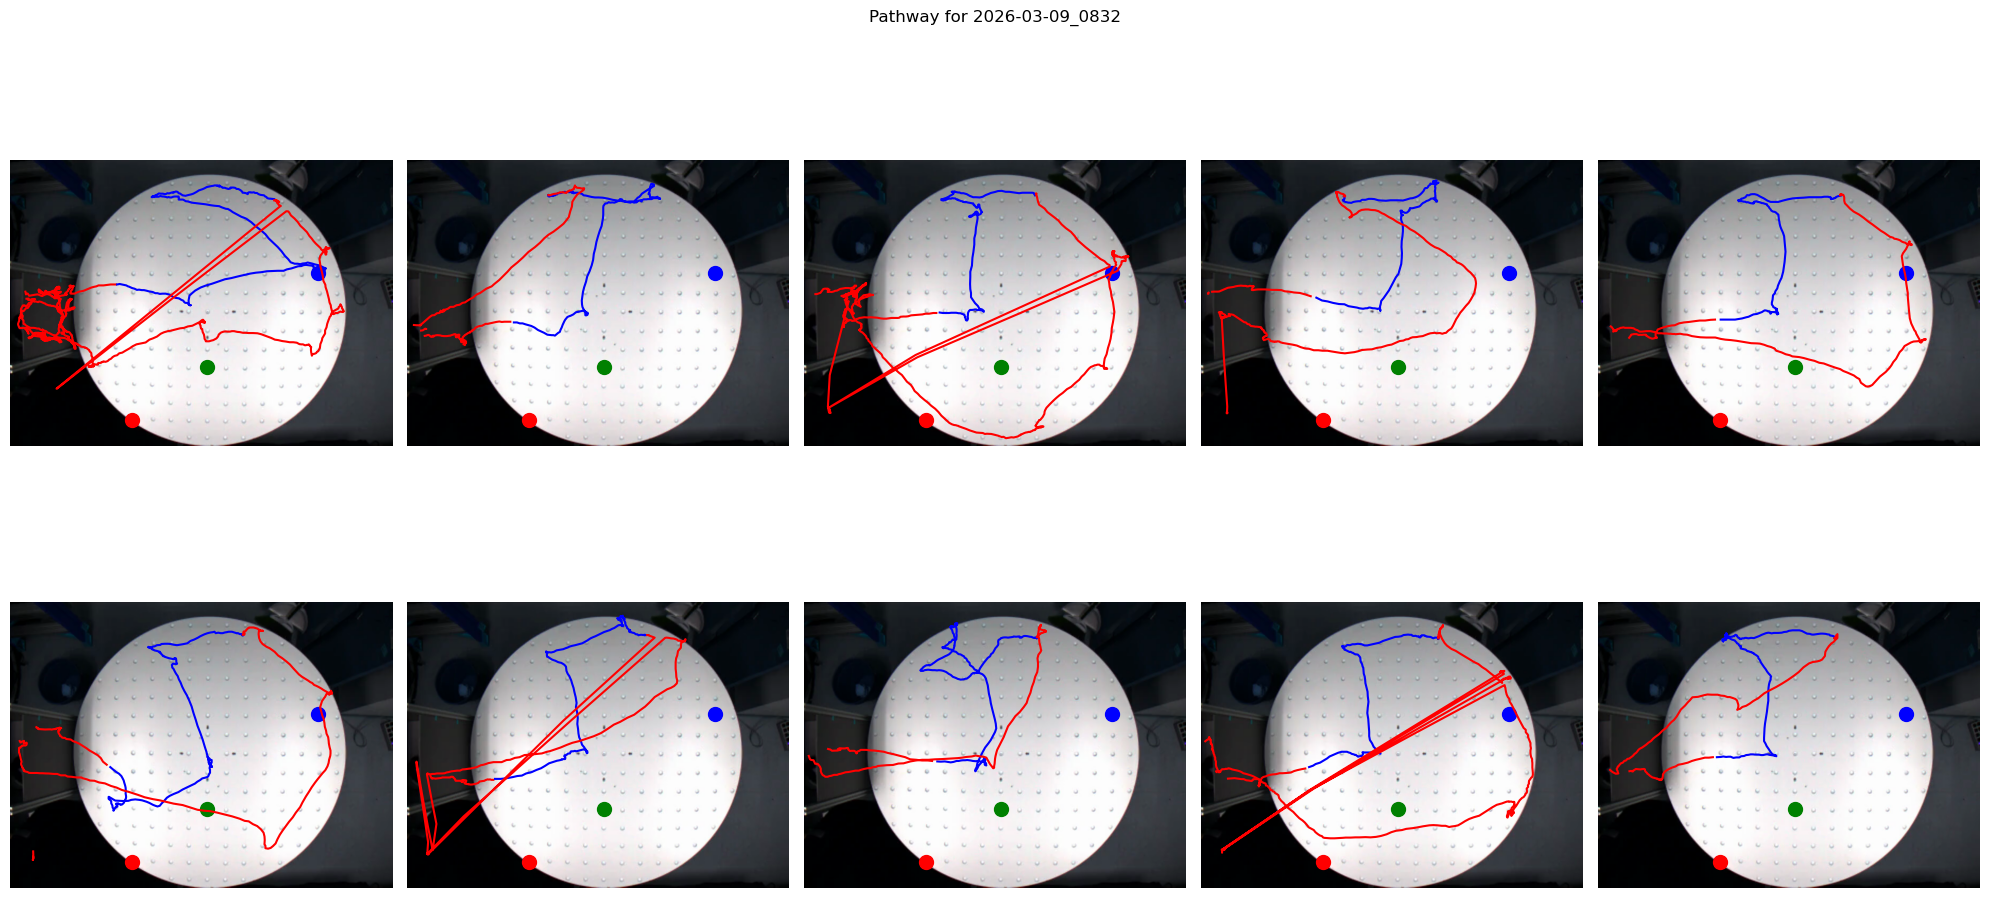

In [21]:
train.plot_all_trials()